In [60]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np

In [61]:
# load in data: we're going to need the model results, experimental data, and parameter dataset.
ROOT = Path.cwd().parent.resolve()
DATA_DIR = ROOT / "data"
model_results = pd.read_csv(DATA_DIR / "results" / "_deterministic_wltp_results.csv")
exp_data = pd.read_csv(DATA_DIR / "processed" / "MLP001_wltp_25degC_record_deq.csv")
param_data = pd.read_csv(DATA_DIR / "processed" / "MLP001_params.csv")
ocv_data = pd.read_csv(DATA_DIR / "processed" / "MLP001_ocv.csv")

In [62]:
def print_stages(model_df, stage_col="Cycle Stage", highlight_stage=None):
    """print the stages and their length one by by one, for sense checking"""
    stages = model_df[stage_col].to_numpy()
    n = len(stages)
    # find run boundaries
    change_points = np.where(stages[1:] != stages[:-1])[0] + 1
    run_starts = np.concatenate(([0], change_points))
    run_ends = np.concatenate((change_points, [n]))

    for i in range(len(run_starts)):
        start, end = run_starts[i], run_ends[i]
        if highlight_stage and stages[start] == highlight_stage:
            print(f"STAGE: {stages[start]}, LENGTH: {end - start}")
        elif not highlight_stage:
            print(f"Stage: {stages[start]}, Length: {end - start}")


In [63]:
def filter_trans_schmitt(model_df, current_col="I [A]", high_threshold=0.01, low_threshold=0.005):
    model_df = model_df.copy()
    model_df["Filtered Stage"] = "Unknown"
    above_high = model_df[current_col] > high_threshold
    below_low = model_df[current_col] < low_threshold

    # Initialize the state
    state = "Discharge"

    for i in range(len(model_df)):
        if above_high[i]:
            state = "Discharge"
        elif below_low[i]:
            state = "Rest"
        # Assign the current state to the Filtered Stage column
        model_df.at[i, "Filtered Stage"] = state

    return model_df

In [64]:
# add in model error, remove points where soc is too low and might throw off values.

model_results["model_error"] = np.abs(model_results["v_cell [V]"] - exp_data["Voltage(V)"].values)
model_results = model_results[model_results["soc"] > 0.15].copy()

In [65]:

current_threshold_high = 0.001
current_threshold_low = 0.0005
model_results_schmitt = filter_trans_schmitt(model_results, current_col="I [A]", high_threshold=current_threshold_high, low_threshold=current_threshold_low)


In [66]:
def get_per_point_run_length(stage_series):
    stages = stage_series.to_numpy()
    n = len(stages)
    change_points = np.where(stages[1:] != stages[:-1])[0] + 1
    run_starts = np.concatenate(([0], change_points))
    run_ends = np.concatenate((change_points, [n]))
    run_lengths = run_ends - run_starts

    per_point_len = np.empty(n, dtype=int)
    for start, end, length in zip(run_starts, run_ends, run_lengths):
        per_point_len[start:end] = length
    return per_point_len

model_results_schmitt["run_length"] = get_per_point_run_length(model_results_schmitt["Filtered Stage"])

rest_mask = model_results_schmitt["Filtered Stage"] == "Rest"
model_results_schmitt.loc[rest_mask, "Filtered Stage"] = np.where(
    model_results_schmitt.loc[rest_mask, "run_length"] < 8000, "Interpulse Rest", "Equilibrium Rest"
)

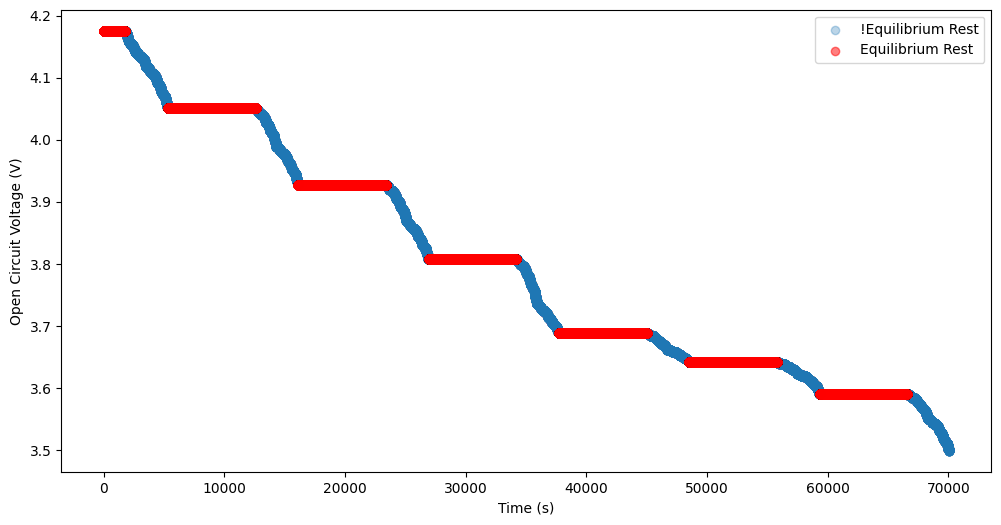

In [67]:
# now, we can remove all records in the equilibrium rest stage, since these are effectively our steady states and don't need to downsample all of them.
model_res_no_ss = model_results_schmitt[model_results_schmitt["Filtered Stage"] != "Equilibrium Rest"].copy()
eq_stages = model_results_schmitt[model_results_schmitt["Filtered Stage"] == "Equilibrium Rest"]
#plot the results to check that the filtering worked as expected.


#plot the results to check that the filtering worked as expected.
plt.figure(figsize=(12, 6))

plt.scatter(model_res_no_ss["t [s]"], model_res_no_ss["v_oc [V]"], label = "!Equilibrium Rest", alpha=0.3)
#plt.scatter(model_results_schmitt["t [s]"], model_results_schmitt["v_oc [V]"], label="original df", alpha=0.3)
plt.scatter(eq_stages["t [s]"], eq_stages["v_oc [V]"], label="Equilibrium Rest", color="red", alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Open Circuit Voltage (V)")
# Highlight the different stages with different colors
plt.legend()
plt.show()

In [68]:
param_data.columns

Index(['SOC', 'R0 [Ohm]', 'R1 [Ohm]', 'R2 [Ohm]', 'tau1 [s]', 'tau2 [s]',
       'Temperature_degC'],
      dtype='object')

In [69]:
# okay, this confirms everything is working as expected. Now, we can get socs just based on the filtered dataframe. Each time taking the mean value 
socs = model_res_no_ss.groupby("Filtered Stage")["soc"].mean()
# we'll just take the param socs at 25 degrees.
param_25degs = param_data[param_data["Temperature_degC"] == 25.0]
known_socs = param_25degs["SOC"].to_numpy()

model_results["nearest_known_param_soc"] = model_results["soc"].apply(lambda x: min(known_socs, key=lambda y: abs(y - x)))
model_results["distance_to_nearest_known_param_soc"] = np.abs(model_results["soc"] - model_results["nearest_known_param_soc"])

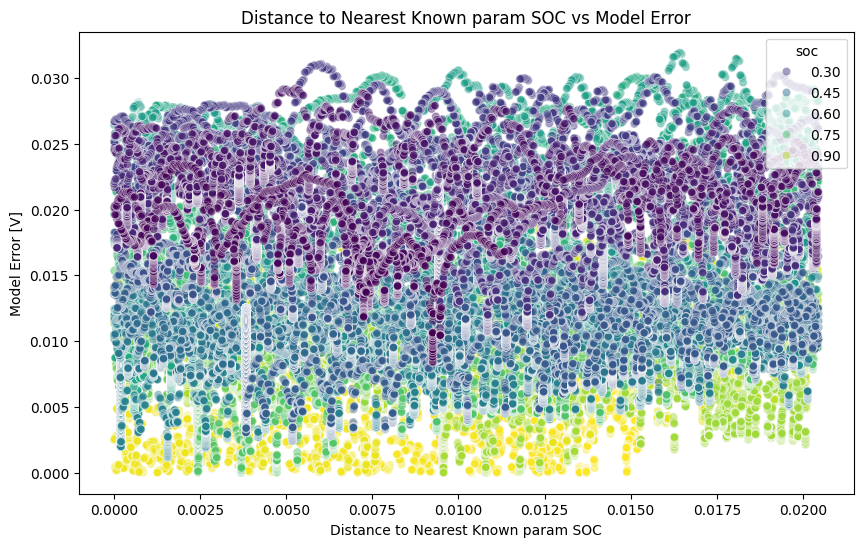

In [85]:
# see if this plot looks at all different now steady states are removed. 
# plot this for sense checking
plt.figure(figsize=(10, 6))
sns.scatterplot(data=model_results, x="distance_to_nearest_known_param_soc", y="model_error", hue=model_results['soc'], palette='viridis', alpha=0.5)
plt.title("Distance to Nearest Known param SOC vs Model Error")
plt.xlabel("Distance to Nearest Known param SOC")
plt.ylabel("Model Error [V]")
plt.show()

In [72]:
# try and plot the c.c again:


correlation_coefficient = model_results["distance_to_nearest_known_param_soc"].corr(model_results["model_error"])
print(f"Correlation coefficient between distance to nearest known Param SOC and model error: {correlation_coefficient}")

# is this a statistically significant correlation? Let's calculate the p-value for this correlation coefficient.
from scipy.stats import pearsonr
corr_coef, p_value = pearsonr(model_results["distance_to_nearest_known_param_soc"], model_results["model_error"])
print(f"Pearson correlation coefficient: {corr_coef}, p-value: {p_value}, datapoints: {len(model_results)}")
# is this statistically significant? Let's use a significance level of 0.05.
alpha = 0.05
if p_value < alpha:
    print("The correlation is statistically significant.")
else:
    print("The correlation is not statistically significant.")



Correlation coefficient between distance to nearest known Param SOC and model error: 0.31199533780249505
Pearson correlation coefficient: 0.31199533780249544, p-value: 0.0, datapoints: 350296
The correlation is statistically significant.


In [ ]:
ocv_25deg = ocv_data[ocv_data["Temperature_degC"] == 25.0].copy()
known_ocv_socs = ocv_25deg["SOC"].to_numpy()

model_results["nearest_known_ocv_soc"] = model_results["soc"].apply(lambda x: min(known_ocv_socs, key=lambda y: abs(y - x)))
model_results["distance_to_nearest_known_ocv_soc"] = np.abs(model_results["soc"] - model_results["nearest_known_ocv_soc"])

Correlation coefficient between distance to nearest known OCV SOC and model error: -0.2582670972458864
Pearson correlation coefficient: -0.2582670972458911, p-value: 0.0, datapoints: 350296
The correlation is statistically significant.


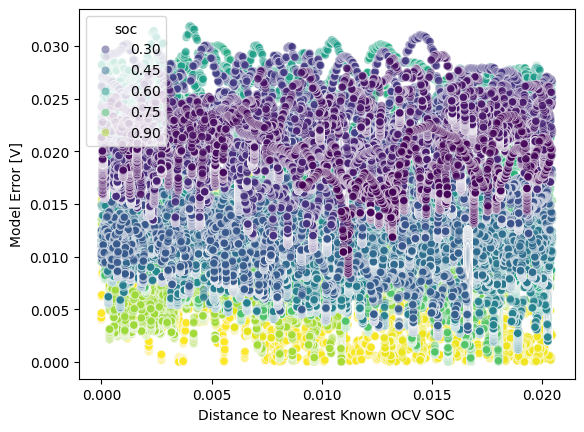

In [ ]:
#plot:
sns.scatterplot(data=model_results, x="distance_to_nearest_known_ocv_soc", y="model_error", hue=model_results['soc'], palette='viridis', alpha=0.5)
plt.xlabel("Distance to Nearest Known OCV SOC")
plt.ylabel("Model Error [V]")


correlation_coefficient = model_results["distance_to_nearest_known_ocv_soc"].corr(model_results["model_error"])
print(f"Correlation coefficient between distance to nearest known OCV SOC and model error: {correlation_coefficient}")

# is this a statistically significant correlation? Let's calculate the p-value for this correlation coefficient.
from scipy.stats import pearsonr
corr_coef, p_value = pearsonr(model_results["distance_to_nearest_known_ocv_soc"], model_results["model_error"])
print(f"Pearson correlation coefficient: {corr_coef}, p-value: {p_value}, datapoints: {len(model_results)}")
# is this statistically significant? Let's use a significance level of 0.05.
alpha = 0.05
if p_value < alpha:
    print("The correlation is statistically significant.")
else:
    print("The correlation is not statistically significant.")

# separate the socs into bins based on the known socs in the param dataset. Then, we can calculate the mean model error for each bin and plot that against the mean distance to nearest known param soc for each bin. This will give us a better idea of how the model error varies with distance to nearest known param soc across different soc ranges.


         t [s]       soc  v_oc [V]  v_rc1 [V]  v_rc2 [V]  v_cell [V]  \
69998  13999.0  0.849479   4.00867   0.002767   0.005218    4.000685   
69999  13999.2  0.849479   4.00867   0.002677   0.005190    4.000804   
70000  13999.4  0.849479   4.00867   0.002589   0.005162    4.000920   
70001  13999.6  0.849479   4.00867   0.002504   0.005134    4.001032   
70002  13999.8  0.849479   4.00867   0.002422   0.005106    4.001142   

          T [°C]  r0 [Ohm]  r1 [Ohm]  r2 [Ohm]    c1 [F]     c2 [F]  I [A]  \
69998  25.001671  0.053866  0.010033  0.019759  6.011058  37.166125   -0.0   
69999  25.001653  0.053866  0.010033  0.019759  6.011067  37.166196   -0.0   
70000  25.001635  0.053866  0.010033  0.019759  6.011075  37.166266   -0.0   
70001  25.001617  0.053866  0.010033  0.019759  6.011083  37.166336   -0.0   
70002  25.001599  0.053866  0.010033  0.019759  6.011092  37.166406   -0.0   

       model_error  nearest_known_param_soc  \
69998     0.006285                 0.856814   
6999

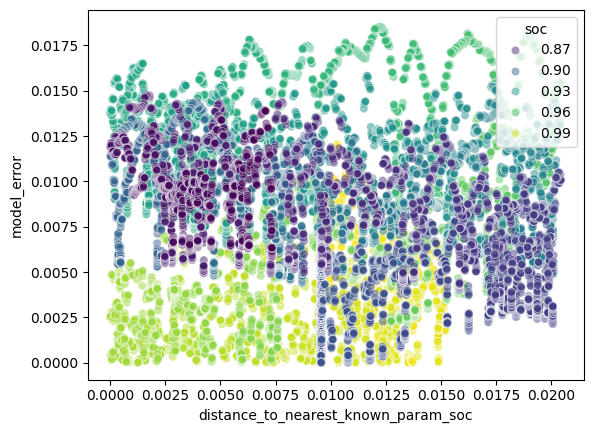

<Axes: xlabel='distance_to_nearest_known_ocv_soc', ylabel='model_error'>

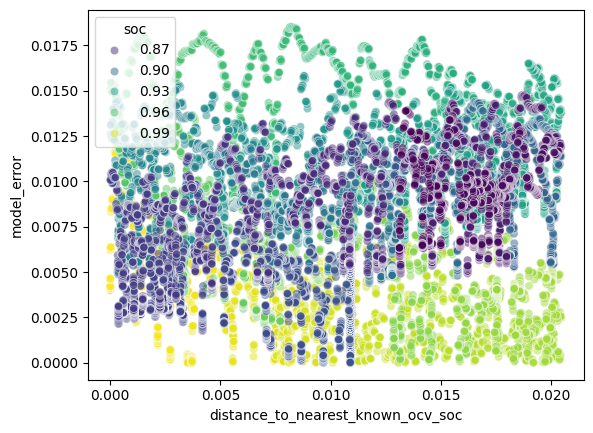

In [93]:
# just plot for the first pulse.

model_results_first_pulse = model_results[model_results["t [s]"] < 14000].copy()
print(model_results_first_pulse.tail())
sns.scatterplot(data=model_results_first_pulse, x="distance_to_nearest_known_param_soc", y="model_error", hue=model_results_first_pulse['soc'], palette='viridis', alpha=0.5)
plt.show()
sns.scatterplot(data=model_results_first_pulse, x="distance_to_nearest_known_ocv_soc", y="model_error", hue=model_results_first_pulse['soc'], palette='viridis', alpha=0.5)